In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
# 忽略无关警告
warnings.filterwarnings("ignore")


===== 数据前3行 =====
      Budget     Revenue                                        Title  Average Vote release_date  Release Year  Starring Actors Popularity
0   92620000      650422                                   Metropolis           8.0    1927/1/10          1927                    0.000000
1  380000000  1045713802  Pirates of the Caribbean: On Stranger Tides           6.4    2011/5/14          2011                 7103.622020
2  300000000   961000000     Pirates of the Caribbean: At World's End           6.9    2007/5/19          2007                 4383.529869

===== 数据后2行 =====
      Budget  Revenue         Title  Average Vote release_date  Release Year  Starring Actors Popularity
3226       1  8500000  Modern Times           8.1     1936/2/5          1936                    0.000000
3227       7        7  Bran Nue Dae           5.2     2009/8/9          2009                 1619.208645

任务2完成，保存数据行数: 3228
任务3完成，筛选数据行数: 2243
任务4完成，已转换为Excel文件
任务5完成，图表已保存为movies_trend_1950_2010.

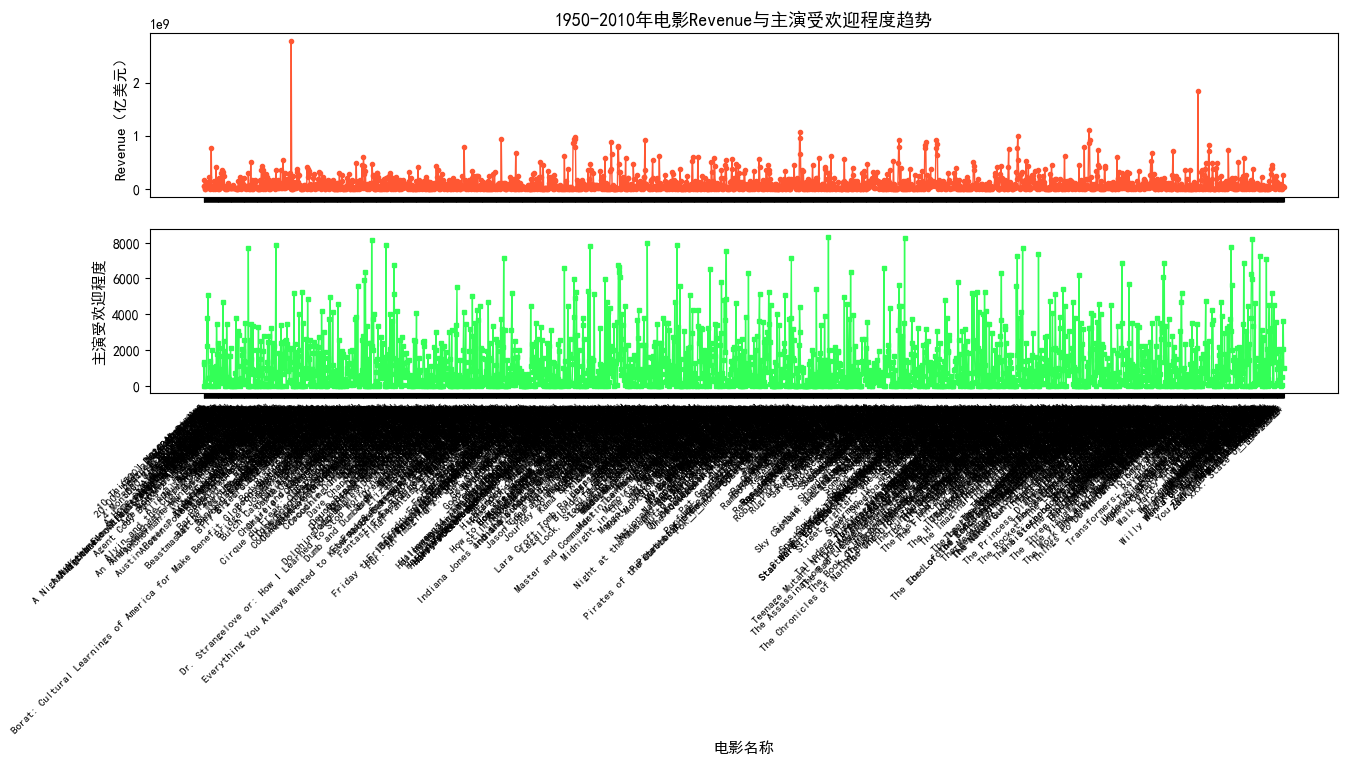

In [3]:
# ---------------------- 任务1：读取数据并查看首尾行 ----------------------
try:
    # 尝试多种编码读取（优先utf-8，失败则用latin-1）
    try:
        df = pd.read_csv('21.movies.csv', encoding='utf-8-sig')
    except UnicodeDecodeError:
        df = pd.read_csv('21.movies.csv', encoding='latin-1')
    
    # 检查关键列是否存在（避免列名错误）
    required_columns = ['Budget', 'Release Year', 'Revenue', 'Title', 'Starring Actors Popularity']
    missing_cols = [col for col in required_columns if col not in df.columns]
    if missing_cols:
        raise ValueError(f"数据缺少关键列: {missing_cols}")

    print("===== 数据前3行 =====")
    print(df.head(3).to_string())  # 避免列截断
    print("\n===== 数据后2行 =====")
    print(df.tail(2).to_string())

# ---------------------- 任务2：筛选列并去重保存 ----------------------
    selected_df = df[required_columns].dropna()  # 直接用检查过的列名
    selected_df.to_csv('movies_revenue_starring.csv', index=False)
    print(f"\n任务2完成，保存数据行数: {len(selected_df)}")

# ---------------------- 任务3：筛选1950-2010年数据保存为TXT ----------------------
    # 确保"Release Year"是数值类型（处理可能的字符串格式）
    df['Release Year'] = pd.to_numeric(df['Release Year'], errors='coerce')
    filtered_df = selected_df[
        (selected_df['Release Year'] > 1950) & 
        (selected_df['Release Year'] < 2010)
    ].copy()  # 避免SettingWithCopyWarning

    # 保存为TXT（使用逗号分隔）
    filtered_df.to_csv('movies_revenue_starring_1950_2010.txt', sep=',', index=False)
    print(f"任务3完成，筛选数据行数: {len(filtered_df)}")

# ---------------------- 任务4：TXT转Excel ----------------------
    txt_df = pd.read_csv('movies_revenue_starring_1950_2010.txt', sep=',')
    txt_df.to_excel('movies_revenue_starring_1950_2010.xlsx', index=False)
    print("任务4完成，已转换为Excel文件")

# ---------------------- 任务5：绘制双变量趋势图 ----------------------
    # 按电影名称排序（避免乱序）
    sorted_df = filtered_df.sort_values('Title')

    # 配置绘图参数
    plt.rcParams.update({
        'font.sans-serif': ['SimHei', 'Microsoft YaHei'],  # 优先系统已安装字体
        'axes.unicode_minus': False,
        'figure.figsize': (14, 8),
        'font.size': 10
    })

    # 创建双子图
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

    # 绘制Revenue趋势
    ax1.plot(sorted_df['Title'], sorted_df['Revenue'], 
            color='#FF5733', marker='o', markersize=3, linewidth=1)
    ax1.set_ylabel('Revenue（亿美元）', fontsize=11)
    ax1.set_title('1950-2010年电影Revenue与主演受欢迎程度趋势', fontsize=13)

    # 绘制主演受欢迎程度趋势
    ax2.plot(sorted_df['Title'], sorted_df['Starring Actors Popularity'], 
            color='#33FF57', marker='s', markersize=3, linewidth=1)
    ax2.set_ylabel('主演受欢迎程度', fontsize=11)
    ax2.set_xlabel('电影名称', fontsize=11)

    # 优化x轴标签（旋转45度+自动调整间距）
    plt.xticks(rotation=45, ha='right', fontsize=8)
    fig.tight_layout(pad=2)  # 增加子图间距

    # 保存高清图
    plt.savefig('movies_trend_1950_2010.png', dpi=300, bbox_inches='tight')
    print("任务5完成，图表已保存为movies_trend_1950_2010.png")

except Exception as e:
    print(f"执行过程中发生错误: {str(e)}")

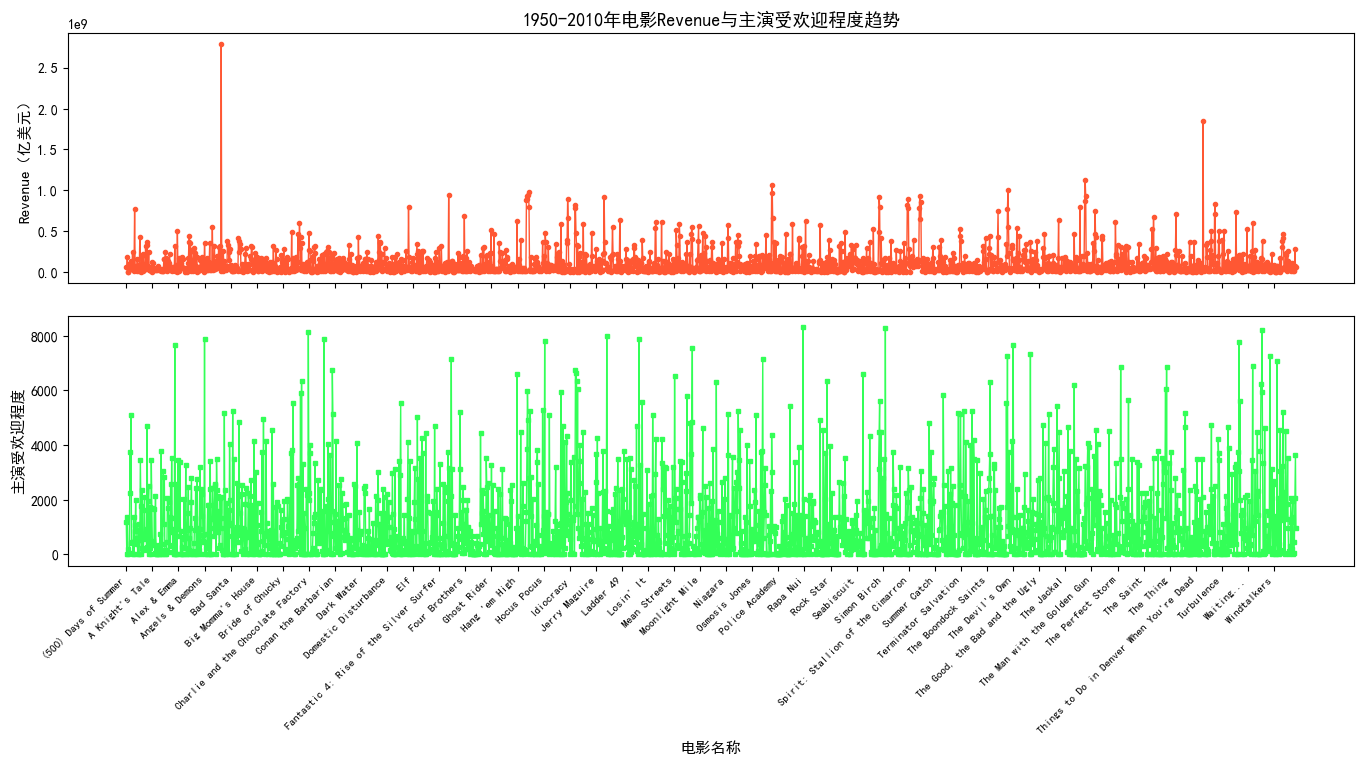

In [11]:
sorted_df = filtered_df.sort_values('Title')

# 配置绘图参数
plt.rcParams.update({
    'font.sans-serif': ['SimHei', 'Microsoft YaHei'],  # 优先系统已安装字体
    'axes.unicode_minus': False,
    'figure.figsize': (14, 8),
    'font.size': 10
})

# 创建双子图
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# 绘制Revenue趋势
ax1.plot(sorted_df['Title'], sorted_df['Revenue'],
        color='#FF5733', marker='o', markersize=3, linewidth=1)
ax1.set_ylabel('Revenue（亿美元）', fontsize=11)
ax1.set_title('1950-2010年电影Revenue与主演受欢迎程度趋势', fontsize=13)

# 绘制主演受欢迎程度趋势
ax2.plot(sorted_df['Title'], sorted_df['Starring Actors Popularity'],
        color='#33FF57', marker='s', markersize=3, linewidth=1)
ax2.set_ylabel('主演受欢迎程度', fontsize=11)
ax2.set_xlabel('电影名称', fontsize=11)
# 优化x轴标签（旋转45度+自动调整间距）
xticksloc = [i for i in range(len(sorted_df['Title'])) if i % 50 == 0]
xtickslabels = sorted_df['Title'].values[::50]
plt.xticks(xticksloc, xtickslabels, rotation=45, ha='right', fontsize=8)
fig.tight_layout(pad=2)  # 增加子图间距
plt.show()

xlengtn= 2243
xticksloc= [0, 300, 600, 900, 1200, 1500, 1800, 2100]
xtickslabels= ['脙聠on Flux' 'The Rocker' 'The Blair Witch Project' 'Road Trip'
 "Max Keeble's Big Move" 'Halloween' 'Daddy Day Care' 'Anaconda']


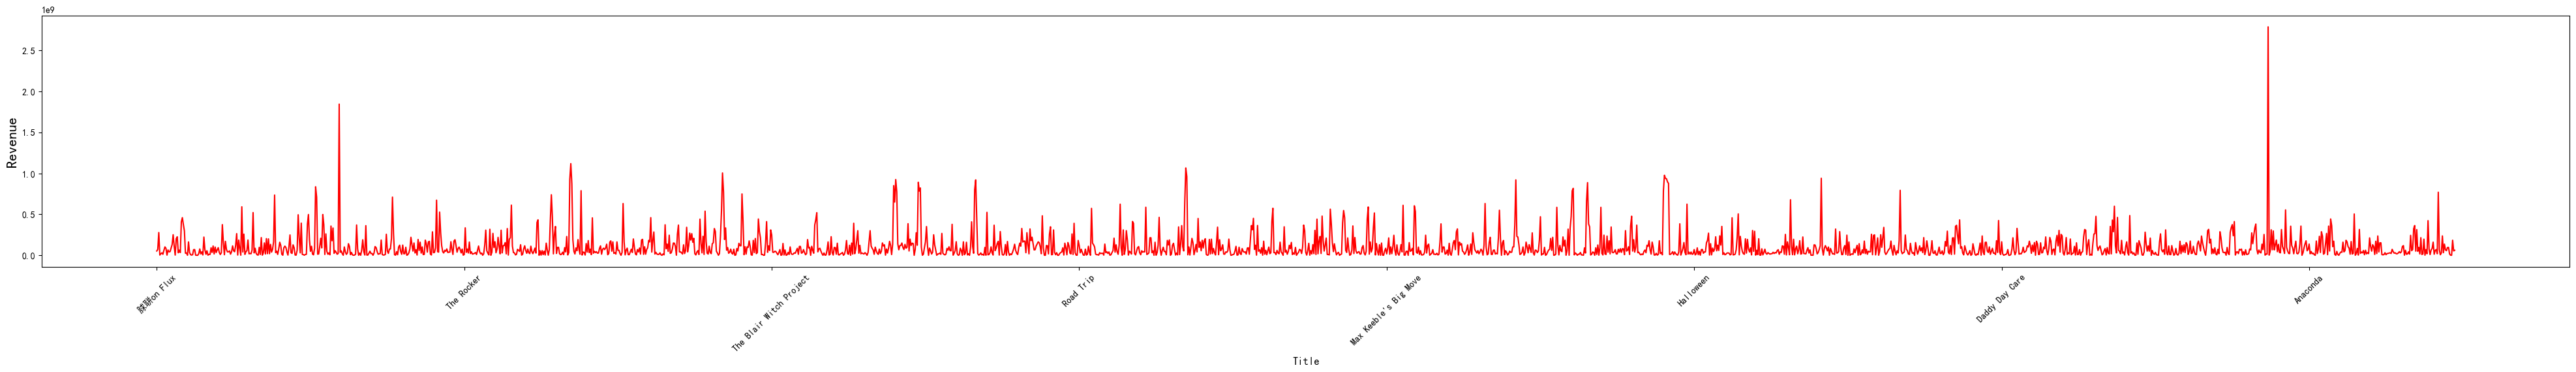

xlengtn= 2243
xticksloc= [0, 300, 600, 900, 1200, 1500, 1800, 2100]
xtickslabels= ['脙聠on Flux' 'The Rocker' 'The Blair Witch Project' 'Road Trip'
 "Max Keeble's Big Move" 'Halloween' 'Daddy Day Care' 'Anaconda']


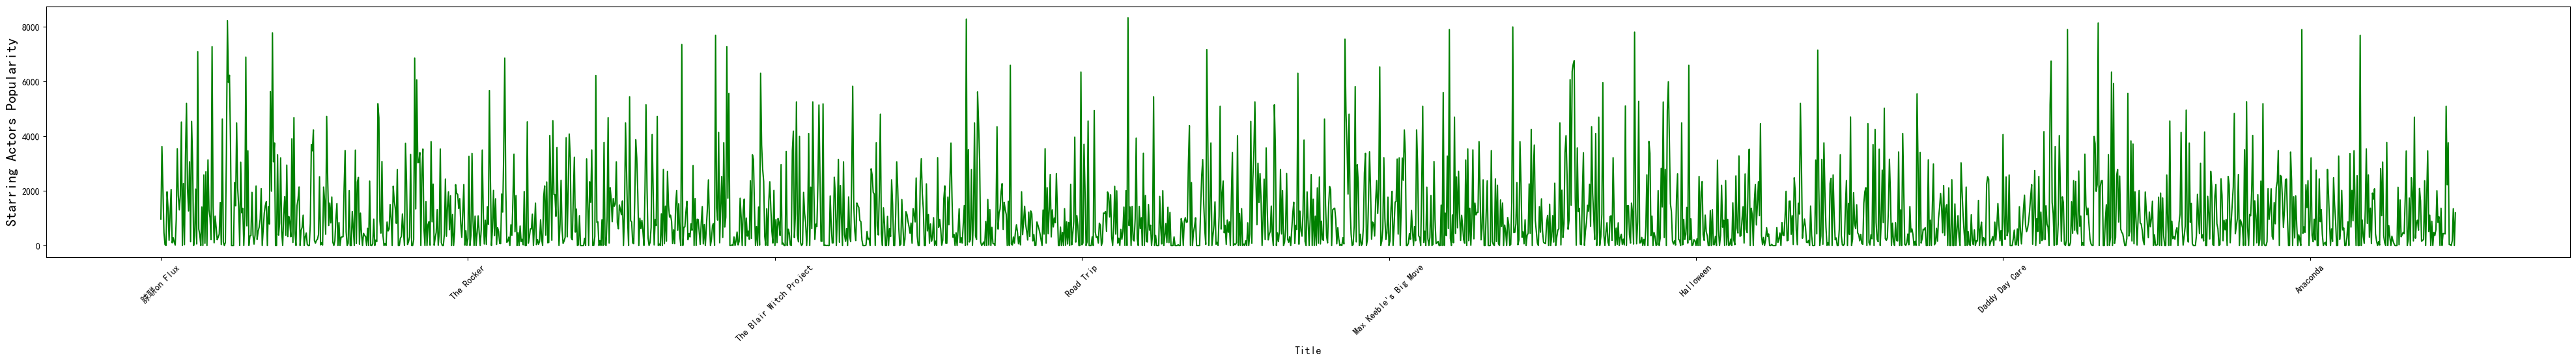

任务五执行成功


In [13]:
fileName = 'movies_revenue_starring_1950_2010.txt'
df_mean = pd.read_csv(fileName, encoding='cp936')
df_mean = df_mean.loc[:, ['Title', 'Revenue']]
df_mean = df_mean.sort_values(by='Title', ascending=False)
plt.figure(figsize=(50, 5))
plt.plot(range(len(list(df_mean['Title']))), df_mean['Revenue'], color='red')
plt.xlabel('Title', fontsize=12)
xlength = len(df_mean)
print('xlengtn=', xlength)
xticksloc = [i for i in range(xlength) if i % 300 == 0]
print('xticksloc=', xticksloc)
xtickslabels = df_mean['Title'].values[::300]
print('xtickslabels=', xtickslabels)
plt.xticks(xticksloc, xtickslabels, rotation=45)  # 刻标，标签，角度
plt.ylabel('Revenue', fontsize=16)
plt.savefig('movies_revenue_1950_2010.png', dpi=400)
plt.show()

df_mean = pd.read_csv(fileName, encoding='cp936')
df_mean = df_mean.sort_values(by='Title', ascending=False)
df_mean = df_mean.loc[:, ['Title', 'Starring Actors Popularity']]
plt.figure(figsize=(50, 5))
plt.plot(range(len(list(df_mean['Title']))), df_mean['Starring Actors Popularity'], color='green')
plt.xlabel('Title', fontsize=12)
xlength = len(df_mean)
print('xlengtn=', xlength)
xticksloc = [i for i in range(xlength) if i % 300 == 0]
print('xticksloc=', xticksloc)
xtickslabels = df_mean['Title'].values[::300]
print('xtickslabels=', xtickslabels)
plt.xticks(xticksloc, xtickslabels, rotation=45)
plt.ylabel('Starring Actors Popularity', fontsize=16)
plt.savefig('movies_starpopularity_1950_2010.png', dpi=400)
plt.show()
print('任务五执行成功')